Kích thước X (Ảnh): (21165, 128, 128)
Kích thước y (Nhãn): (21165,)


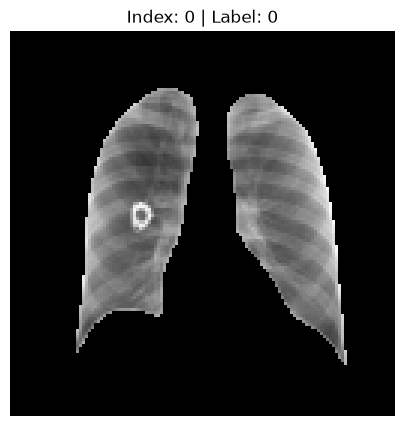

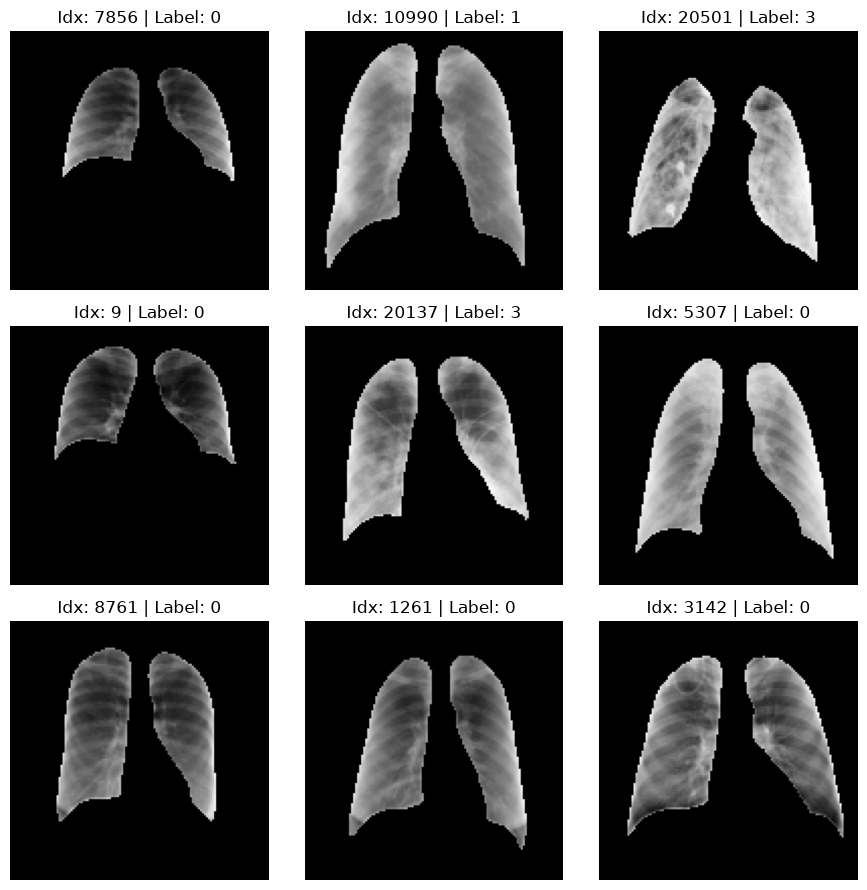

In [1]:
import sys
import matplotlib.pyplot as plt
import numpy as np


def show_single_sample(images_path, labels_path, index=0):
    """Hiển thị 1 ảnh cụ thể cùng với nhãn tương ứng."""
    try:
        X = np.load(images_path)
        y = np.load(labels_path)

        print(f"Kích thước X (Ảnh): {X.shape}")
        print(f"Kích thước y (Nhãn): {y.shape}")

        if index >= len(X):
            print(
                f"Lỗi: Index {index} vượt quá số lượng mẫu dữ liệu ({len(X)})."
            )
            return

        img = X[index]
        label = y[index]

        # Nếu img có dạng (128, 128, 1) -> đưa về (128, 128)
        if img.ndim == 3 and img.shape[-1] == 1:
            img = img.squeeze()

        plt.figure(figsize=(5, 5))
        plt.imshow(img, cmap="gray")
        plt.title(f"Index: {index} | Label: {label}")
        plt.axis("off")
        plt.show()

    except FileNotFoundError as e:
        print(f"Không tìm thấy file: {e}")
    except Exception as e:
        print(f"Đã xảy ra lỗi: {e}")


def show_random_batch(images_path, labels_path, num_samples=9):
    """Hiển thị một lưới gồm nhiều ảnh ngẫu nhiên kèm nhãn để trực quan hóa toàn bộ tập dữ liệu."""
    try:
        X = np.load(images_path)
        y = np.load(labels_path)

        # Chọn ngẫu nhiên num_samples chỉ số ảnh
        indices = np.random.choice(len(X), size=num_samples, replace=False)

        cols = 3
        rows = (num_samples + cols - 1) // cols
        plt.figure(figsize=(3 * cols, 3 * rows))

        for idx, img_idx in enumerate(indices):
            img = X[img_idx]
            label = y[img_idx]

            if img.ndim == 3 and img.shape[-1] == 1:
                img = img.squeeze()

            plt.subplot(rows, cols, idx + 1)
            plt.imshow(img, cmap="gray")
            plt.title(f"Idx: {img_idx} | Label: {label}")
            plt.axis("off")

        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Đã xảy ra lỗi: {e}")


if __name__ == "__main__":
    # Thay đổi đường dẫn đến 2 file .npy của bạn
    images_path = "Data/Processed/x_resized_masked.npy"
    labels_path = "Data/Processed/y_labels.npy"  # Thay bằng tên file label thực tế

    # 1. Hiển thị 1 tấm ảnh cụ thể tại index 0
    show_single_sample(images_path, labels_path, index=0)

    # 2. Hoặc hiển thị ngẫu nhiên 9 tấm ảnh cùng lúc (Bỏ comment dòng dưới để dùng)
    show_random_batch(images_path, labels_path, num_samples=9)